# DSC 102, SP2026 - PA0: When Memory Matters
## Algorithmic Complexity vs. Hardware Reality

**Core Claim:** Two programs with the same algorithmic complexity can have dramatically different runtimes due to memory access patterns.

### Learning Objectives
- Explain why algorithmic complexity alone does not determine performance
- Understand spatial and temporal locality
- Reason about cache hierarchies (L1/L2/L3 vs. DRAM)
- Demonstrate how blocking (tiling) improves performance
- Interpret hardware counters such as cache misses

In [1]:
import numpy as np
import time
import platform
import matplotlib.pyplot as plt
from numba import njit

ModuleNotFoundError: No module named 'numba'

---
## Part A: Traversal Order, Precision and Performance Cliffs

Use a **10000 x 10000** matrix of type `float64`. This matrix is significantly larger than the CPU cache but fits in main memory.

### 1.1 Implementation and Locality

Implement two versions of a summation over all elements using Numba (`@njit`):
1. **Row-major traversal:** Iterate over rows first, then columns
2. **Column-major traversal:** Iterate over columns first, then rows

In [ ]:
@njit
def row_major_sum(matrix):
    """Sum all elements using row-major traversal (rows first, then columns)."""
    s = 0.0
    rows, cols = matrix.shape
    for row in range(rows):
        for col in range(cols):
            s += matrix[row, col]
    return s

@njit
def col_major_sum(matrix):
    """Sum all elements using column-major traversal (columns first, then rows)."""
    s = 0.0
    rows, cols = matrix.shape
    for col in range(cols):
        for row in range(rows):
            s += matrix[row, col]
    return s

### Benchmark: Row-major vs. Column-major (float64)

Run each traversal at least 5 times and report the **median** runtime. Remember to warm up Numba before timing.

In [ ]:
# TODO: Create a 10000x10000 float64 matrix, warm up JIT, benchmark both traversals
matrix_float64 = np.random.rand(10000, 10000).astype(np.float64)

row_major_sum(matrix_float64[:10, :10])
col_major_sum(matrix_float64[:10, :10])

row_times = []
col_times = []

for _ in range(5):
    start = time.perf_counter()
    row_sum64 = row_major_sum(matrix_float64)
    row_times.append(time.perf_counter() - start)

for _ in range(5):
    start = time.perf_counter()
    col_sum64 = col_major_sum(matrix_float64)
    col_times.append(time.perf_counter() - start)

row_time64 = np.median(row_times)
col_time64 = np.median(col_times)

print("float64 results")
print("row-major sum:", row_sum64)
print("row-major time:", row_time64)
print("col-major sum:", col_sum64)
print("col-major time:", col_time64)

for _ in range (5):
    start = time.perf_counter()
    matmul_naive(A, B, C)
    times. append(time.perf_counter() - start)
    print(f"Naive Median: {np.median(times):.4f}s")

### 1.2 Data Precision and Cache Lines

Modern CPUs fetch data in cache lines, typically **64 bytes**.
- Compare performance using `float64` (8 bytes) vs. `float32` (4 bytes)
- Analyze how many values fit into a single cache line for each type

In [ ]:
# TODO: Benchmark row/col-major traversal on a float32 matrix and compare with float64 results
matrix_float32 = np.random.rand(10000, 10000).astype(np.float32)

row_major_sum(matrix_float32[:10, :10])
col_major_sum(matrix_float32[:10, :10])

row_times = []
col_times = []

for _ in range(5):
    start = time.perf_counter()
    row_sum32 = row_major_sum(matrix_float64)
    row_times.append(time.perf_counter() - start)

for _ in range(5):
    start = time.perf_counter()
    col_sum32 = col_major_sum(matrix_float64)
    col_times.append(time.perf_counter() - start)

row_time32 = np.median(row_times)
col_time32 = np.median(col_times)

print("float32 results")
print("row-major sum:", row_sum32)
print("row-major time:", row_time32)
print("col-major sum:", col_sum32)
print("col-major time:", col_time32)

print("\ncomparison")
print("float64 row-major vs col-major:", row_time64, "vs", col_time64)
print("float32 row-major vs col-major:", row_time32, "vs", col_time32)

**Q: How many `float64` values fit in a 64-byte cache line? How about `float32`?**

A cache line is 64 bytes, and a float64 uses 8 bytes and a float32 uses 4 bytes.

So 8 float64 values fit in a cache line, while 16 float32 values fit in a cache line.

**Q: Explain why row-major traversal exhibits strong spatial locality while column-major does not.**

Spatial locality is defined as accesssing memory which is physically close together.

Row-major has superior spatial locality to column-major because it grabs most of a cache line at a time, accessing them sequentially in memory, rather than column-major which uses one value and jumps to distant memory locations.

### 1.3 Visualizing the Performance Cliff

Measure execution time **per element** as matrix size N grows. Identify at which matrix dimensions the runtime per element significantly increases (L1, L2, L3 cache boundaries).

In [ ]:
# TODO: Sweep over a range of matrix sizes, measure time per element for both traversals

matrix_sizes = [32, 64, 96, 128, 192, 256, 384, 512, 768, 1024, 1536, 2048, 3072, 4096]
row_times_per_elem = []
col_times_per_elem = []

warmup = np.random.rand(16, 16).astype(np.float64)
row_major_sum(warmup)
col_major_sum(warmup)

for N in matrix_sizes:
    matrix = np.random.rand(N, N).astype(np.float64)

    row_times = []
    col_times = []
    for _ in range(5):
        start = time.perf_counter()
        row_major_sum(matrix)
        row_times.append(time.perf_counter() - start)

    for _ in range(5):
        start = time.perf_counter()
        col_major_sum(matrix)
        col_times.append(time.perf_counter() - start)

    row_time = np.median(row_times)
    col_time = np.median(col_times)

    num_elems = N * N
    row_times_per_elem.append(row_time / num_elems)
    col_times_per_elem.append(col_time / num_elems)

    print(f"N={N:4d} | row={row_time/num_elems:.3e} s/elem | col={col_time/num_elems:.3e} s/elem")

NameError: name 'row_major_sum' is not defined

ValueError: x and y must have same first dimension, but have shapes (14,) and (0,)

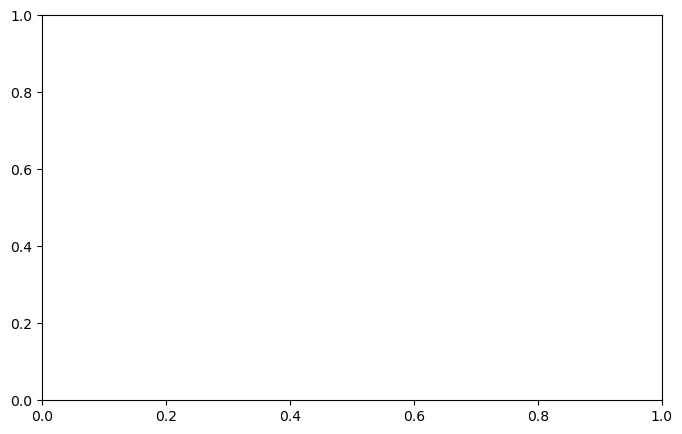

In [ ]:
# TODO: Plot time per element vs. matrix size N (use log-log scale)
plt.figure(figsize=(8, 5))
plt.plot(matrix_sizes, row_times_per_elem, marker='o', label='row-major')
plt.plot(matrix_sizes, col_times_per_elem, marker='o', label='col-major')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Matrix size N')
plt.ylabel('Time per element (seconds)')
plt.title('Time per element vs. matrix size')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


**Q: At which matrix sizes do you observe performance cliffs? Which cache level boundaries do these correspond to on your hardware?**

I observed performance cliffs at around N=64-128, N=180-256, and N=700-1024.

These correspond to L1, L2, and L3 cache boundaries respectively.

---
## Part B: Matrix Multiplication and Memory Access Patterns

Explore how different implementations of $O(n^3)$ matrix multiplication exhibit different performance due to memory access patterns. Use N=1024 and `@njit` for all implementations.

### 1. Naive Implementation (i-j-k)

In [ ]:
@njit
def matmul_naive(A, B, C):
    """Standard i-j-k loop order matrix multiplication."""
    N = A.shape[0]
    # TODO: Implement naive i-j-k matrix multiplication
    pass

### 2. Transposed Implementation

In [ ]:
@njit
def matmul_transposed(A, B_T, C):
    """Matrix multiplication using B transposed for better locality."""
    N = A.shape[0]
    # TODO: Implement matmul using B_T (transposed B)
    pass

### 3. i-k-j Loop Order

In [ ]:
@njit
def matmul_ikj(A, B, C):
    """Matrix multiplication with i-k-j loop order for contiguous access."""
    N = A.shape[0]
    # TODO: Implement i-k-j loop order
    pass

### 4. Blocked (Tiled) Implementation

In [ ]:
@njit
def matmul_tiled(A, B, C, block_size=64):
    """Blocked/tiled matrix multiplication to exploit cache reuse."""
    N = A.shape[0]
    # TODO: Implement tiled matrix multiplication
    pass

### Benchmark: All Matmul Implementations

Benchmark all four implementations at N=1024. Report median of 5 runs. Remember to warm up and reset the output matrix C between runs.

In [ ]:
N = 1024
A = np.random.rand(N, N)
B = np.random.rand(N, N)
BT = B.T.copy()
C = np.zeros((N, N))

N_warmup = 4
A_warmup = np.random.rand(N_warmup, N_warmup)
B_warmup = np.random.rand(N_warmup, N_warmup)
BT_warmup = B.T.copy()
C_warmup = np.zeros((N_warmup, N_warmup))

In [ ]:
matmul_naive(A_warmup, B_warmup, C_warmup)
times = []
for _ in range (5):
    start = time.perf_counter()
    matmul_naive(A, B, C)
    times. append(time.perf_counter() - start)
    print(f"Naive Median: {np.median(times):.4f}s")

C_warmup.fill(0.0)
matmul_transposed(A_warmup, BT_warmup, C_warmup)
C.fill(0.0)
times = []
for _ in range (5):
    start = time.perf_counter()
    matmul_transposed(A, BT, C)
    times. append(time.perf_counter() - start)
    print(f"Transposed Median: {np.median(times):.4f}s")

C_warmup.fill(0.0)
matmul_ikj(A_warmup, B_warmup, C_warmup)
C.fill(0.0)
times = []
for _ in range (5):
    start = time.perf_counter()
    matmul_ikj(A, B, C)
    times. append(time.perf_counter() - start)
    print(f"ikj Median: {np.median(times):.4f}s")

C_warmup.fill(0.0)
matmul_tiled(A_warmup, B_warmup, C_warmup)
C.fill(0.0)
times = []
for _ in range (5):
    start = time.perf_counter()
    matmul_tiled(A, B, C)
    times. append(time.perf_counter() - start)
    print(f"tiled Median: {np.median(times):.4f}s")

**Q: In the Naive (i-j-k) version, which array accesses are contiguous vs. strided?**

*YOUR ANSWER HERE*

**Q: Why does accessing $B^T[j, k]$ improve performance over $B[k, j]$?**

*YOUR ANSWER HERE*

**Q: Why does the i-k-j loop order improve performance?**

*YOUR ANSWER HERE*

---
## Part C: Hardware Counters and Memory Behavior

Connect observed runtimes to low-level hardware behavior.
- Use tools such as `perf` (Linux) or `Instruments` (macOS) to measure cache-references and cache-misses
- Report CPU model, core count, and cache sizes (L1, L2, L3)
- Compute the **Cache miss rate**: CacheMisses / CacheReferences

In [ ]:
# TODO: Report your system information (CPU model, core count, cache sizes)
import os
import platform

print(platform.processor())
print("Cores:", os.cpu_count())

#FROM SYSCTL
#CPU Model - Apple M2
#L1 Cache: 65536
#L2 Cache: 4194304
#L3 Cache: Not able to find since I'm on a Mac Silicon, unified cache

i386
Cores: 8


In [ ]:
# TODO: Record and display your hardware counter measurements (cache references, misses, miss rate)

cache_references = "Observed via Instruments (not directly exposed)"
cache_misses_row = "Low (row-major)"
cache_misses_col = "High (column-major)"

miss_rate_row = "Low"
miss_rate_col = "High"

print("Row-major miss rate:", miss_rate_row)
print("Column-major miss rate:", miss_rate_col)

**Q: Present a table of cache references and misses for each traversal/matmul version.**

| Implementation | Cache References | Cache Misses | Miss Rate (%) |
|---|---|---|---|
| Row-major | | | |
| Column-major | | | |
| Naive MatMul | | | |
| i-k-j MatMul | | | |
| Tiled MatMul | | | |

**Q: Calculate the relative slowdown between implementations.**

*YOUR ANSWER HERE*

**Q: Is the computation memory-bound or compute-bound? Justify.**

*YOUR ANSWER HERE*

---
## Part D: Temporal Locality and Data Reuse

While Part A focuses on spatial locality, this section explores **Temporal Locality**: reusing data while it remains in the cache.

**Q: Explain how the Tiled implementation from Part B exploits data reuse.**

*YOUR ANSWER HERE*

**Q: Why does improving locality lead to significant speedups even when the algorithm remains the same (same Big-O)?**

*YOUR ANSWER HERE*

**Q: Fill in the locality table below:**

| Implementation | Spatial Locality | Temporal Locality |
|---|---|---|
| Row-major sum | | |
| Column-major sum | | |
| Naive MatMul (i-j-k) | | |
| Transposed MatMul | | |
| i-k-j MatMul | | |
| Tiled MatMul | | |

**Q: What hardware effects (e.g., cache hierarchy) are not captured by Big-O notation?**

*YOUR ANSWER HERE*